# JBI030 - Graded Homework Assignment 1

This notebook contains the explanation and the setup code for JBI030 homework assignment 1. 

By completing these exercises you will learn how to:
- Analyze and preprocess a dataset.
- Use optimization techniques to create predictive models for your data.
- Validate the accuracy and correctness of your models.

While also useful in itself, all of these skills serve as the basis for machine learning later on.

## Use Numpy, not AI or Scikit Learn

You could, of course, use AI to complete these assignments for you. 
Similarly, libraries like [scikit learn](https://scikit-learn.org/stable/) contain (amazing) tools that would do most of the work for you.

We recommend against that for a couple of reasons:
- The point of this course is to really understand the basic concepts machine learning is founded on. Using these tools completes the exercises but sabotages your opportunity to understand the material by struggling through it yourself.
- We designed these exercises to be good exam preparation. Specifically we will assume you know how to use [Numpy](https://numpy.org/doc/2.5/) to solve problems like these.

So instead, __learn to use Numpy__! It will build up your understanding of the basics because it connects more directly with the mathematics in this course. Where appropriate we will provide you with setup code. You could use other tools, and discussing with your fellow students of course, to validate your approach.

We hope this gives you plenty of incentive to engage with the material. Struggle is what learning generally feels like on the inside.  

_Side note:_ You might want to check out the scikit learn documentation anyway. The project does an amazing job of explaining some of the core concepts you will be learning about in this course in a different way. 

## Reading documentation

Reading documentation is a good skill to learn. Learn how to read the [Numpy documentation](https://numpy.org/doc/2.5/)! 

[Good documentation](https://diataxis.fr/) is generally divided into tutorials, how-to guides, explanations and API documentation. You should learn when to use each of these types of documentation, and when to skip them. 

A good initial approach is to read the [Numpy beginner tutorial](https://numpy.org/doc/2.5/user/absolute_beginners.html). When you want to figure out what numpy can do more broadly, scan the [Numpy user guide](https://numpy.org/doc/2.5/user/index.html#user), which contains several how-to guides. 

The API documentation works differently, and is really confusing if you treat it as a tutorial like the two aforementioned links. Instead you should treat it as a reference you read when you want to learn more about a specific function or operation in the Numpy library. It becomes very useful that way! Take for instance the API documentation on [np.sin()](https://numpy.org/doc/stable/reference/generated/numpy.sin.html). Read the introduction and then look at the example at the bottom of the page. Skip all the detailed information unless you directly need it. 

## Software libraries

We will use [Numpy](https://numpy.org/doc/) for algorithm implementation, [Pandas](https://pandas.pydata.org/docs/) for data analysis and [Matplotlib](https://matplotlib.org/stable/index.html) for data visualization.

## Dataset

You will be working with the [California housing dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset). We will provide you with the code to load the data. 

## Handing in the exercises

You will use ANS to hand in your answers. You should hand in your code and notes as well.

All answers will be checked automatically and are subject to rounding error. Please copy the whole answers including all decimals. 

# Questions 

![Escher, Relativity, 1953, July](images/Escher-Relativity-1953-July.jpg)

_"Relativity", produced by Dutch artist M.C. Escher in July of 1953. People ascending and descending stairs oriented in defiance of ordinary physics._


## 1. Foundational linear algebra for optimization
This exercise covers some linear algebra necessary for optimization.

Use pen and paper if necessary, and answer the true or false questions below.

Let $X \in \mathbb{R}^{n\times p}$ be a centered data matrix. Each row is one observation. Each column is one feature. Centered means that each column has a mean of zero:
$$\frac{1}{n}\sum_{i=1}^n X_{i,j} = 0 \quad \text{for all } j$$

The sample covariance matrix $C$ has eigendecomposition:

$$C = \frac{1}{n-1} X^\top X = Q \Lambda Q^\top$$

The columns of $Q$ are the eigenvectors. The diagonal matrix $\Lambda$ contains the eigenvalues $\lambda_1, \lambda_2, \ldots, \lambda_p$.

### 1a. Total variance

__Statement.__ 
The total variance of the dataset is:
$$\text{Total sample variance} = \operatorname{tr}(C) = \frac{1}{n-1}\operatorname{tr}(X^\top X) = \lambda_{max}$$

__Answer:__ ☐ True ☐ False

### 1b. Covariance

__Statement.__ For a centered data matrix $X$, this formula gives the sample covariance between feature $j$ and feature $k$:

$$\operatorname{Cov}(j,k) = \frac{1}{n-1} \, X_{(:,j)}^\top X_{(:,k)}$$

The vector $X_{(:,j)}$ is column $j$ of $X$.

__Answer:__ ☐ True ☐ False

### 1c. Covariance under linear transformations

__Statement.__ A linear transformation $Y = XW$, with a transformation matrix $W \in \mathbb{R}^{p\times q}$, gives this covariance matrix for the transformed features:

$$C_Y = W^\top C_X W \qquad \text{with} \qquad C_X = \frac{X^\top X}{n-1}$$

__Answer:__ ☐ True ☐ False


### 1d. Matrix norms and trace

__Statement.__ For any matrix $A \in \mathbb{R}^{n\times p}$, this relation holds between the row-wise and the column-wise squared norms:

$$\operatorname{tr}(A A^\top) = \sum_{i=1}^n \|A_{(i,:)}\|^2 = \sum_{j=1}^p \|A_{(:,j)}\|^2$$

__Answer:__ ☐ True ☐ False

## The California housing dataset

Your task from this point forward is to __create a prediction model for housing prices__, from scratch, using your newfound knowledge of statistical modeling and machine learning. 
We will use data from the California housing dataset to do so.
It is good practice to examine any dataset that you receive before you start modeling. 
We'll go through some basic analysis here.
Feel free to extend the analysis yourself later to get a better feel for the data.
Creating visualizations can be especially helpful when doing so.

After we are done with our initial analysis your next task is to use data normalization techniques on the dataset and examine their effect.



First we load the data from the `data` directory.
Examining the data is fairly straightforward by using the [Pandas](https://pandas.pydata.org/docs/) library.
As mentioned, we will later work with Numpy throughout this course to implement the core algorithms.

In [10]:
# All the necessary imports for the exercises
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
from pathlib import Path
from typing import Callable  # Typehints for the methods you write
from itertools import combinations_with_replacement


In [38]:
data_dir = Path("data/")
feature_path = data_dir / "california_housing_features.parquet"
target_path = data_dir / "california_housing_target.parquet"

# Import dataset
features_table = pq.read_table(feature_path)
pandas_data = features_table.to_pandas()

pandas_target = pq.read_table(target_path).to_pandas().squeeze("columns")
description = features_table.schema.metadata[b"description"].decode()

# Better styling for plotting
plt.style.use('seaborn-v0_8-whitegrid')

# Documentation of the dataset
print(description)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [8]:
# We show the first five entries in the dataset using the head() method
pandas_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
# We can also load the target data
pandas_target.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

Reading the output we can see that we have a dataset with 8 columns describing the properties of houses per "housing block". Each row in the dataset describes a group of houses in a district. The target data is the median price of the houses in each district expressed in $100,000$ dollar units. Let's inspect the data a bit more. Pandas has a nice [describe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html#pandas.DataFrame.describe) method we can use to get some additional information.

In [10]:
pandas_data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


(_Note: Pandas uses [`ddof=1` by default](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.std.html) for `std` calculation. [Numpy uses `ddof=0`](https://numpy.org/doc/stable/reference/generated/numpy.std.html) by default. The results in these tables will differ slightly from Numpy. Both are acceptable, but we will use Numpy by default when possible._)

In [11]:
pandas_target.describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

Now we have a sense of the range of the data. That is good, but having a visual representation might provide better intuition. Let's plot the target, i.e. the median housing price, as a density plot using Matplotlib. Pandas has a method that automatically uses Matplotlib for us.

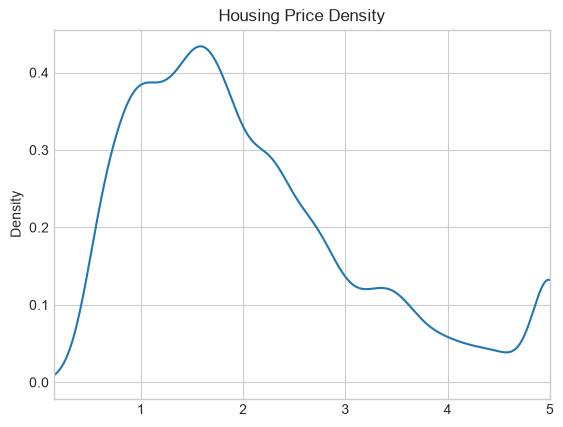

In [12]:
pandas_target.plot.density(
    title="Housing Price Density",
    xlim=(pandas_target.min(), pandas_target.max()),
)
plt.show()

We can see that the median housing price is approximately normally distributed except for a spike near the far end. 
Try to visualize some of the other data yourself to see what you can learn. 

## 2. Data normalization

Raw data features often have very different scales and distributions. 
In the case of the housing price dataset you can see this difference clearly when looking at the minimum and maximum values of `HouseAge` and `Population`. 
You might want to plot both distributions on top of each other to see the difference even more clearly.

This difference in scale can cause problems when modeling data.
Large values might drown out small values, making it harder to train a model.
In extreme instances you might even run into [number precision](https://en.wikipedia.org/wiki/Precision_(computer_science)) errors.

Data normalization techniques can help us by transforming the features so they have a comparable scale. 
Each method operates on different assumptions and has a different impact on your data.
The assignments in this chapter ask you to program several of those data normalization methods and evaluate their effect on the data.


### Normalization techniques

Take a look at the following data normalization techniques so you can implement them later.

#### Min-max scaling

With $x$ being a vector storing all the values in the data, the normalized min-max scaling vector $x_{minmax}$ is defined as:

$$x_{minmax} = \dfrac{x - \min{x}}{\max{x} - \min{x}}$$

Min-max scaling keeps the shape of the distribution the same. 
It uses only the smallest and the largest value, so one outlier can push all the other data into a narrow band. 

#### Standardization (z-score)

Given a data vector $x$, the data mean $\mu$ and standard deviation $\sigma$, the normalized vector for standardization $x_{standardized}$ is defined as:

$$x_{standardized} = \dfrac{x - \mu}{\sigma}$$

This normalization method is most natural when the data is roughly normally distributed. 

#### Robust scaling

Given a data vector $x$, the normalized vector for robust scaling $x_{robust}$ is defined as:


$$x_{robust} = \dfrac{x - \text{median}(x)}{\text{IQR}(x)}$$

$\text{IQR}$ is the interquartile range, $Q3 - Q1$. 
Robust scaling is less sensitive to extreme values.
This property can be nice, unless the extreme values of the data contain crucial information necessary to predict the target, in which case your model might lose some predictive capabilities when using data normalized this way.

### Task

For each of the normalization methods above:
1. Write a function using numpy that takes in a data vector, and returns the normalized vector.
2. Apply each function to the features noted in the setup code in the code cells below.
3. Write the transformed values in the answer form on ANS.

_Optional:_ You can create plots for each normalization method. 
Compare the data before and after the normalization.
Overlap plots for the different normalization techniques to see the differences between the methods for each feature in the dataset.



### 2a. Min-max scaling

Apply min-max scaling to `HouseAge`. 
Report the values of the normalized vector at the requested indexes.



In [14]:
# The requested indexes
min_max_request_indexes = [4242, 8080, 10000]

# Transform pandas data to numpy first
data_in = pandas_data["HouseAge"].to_numpy()

In [15]:
# TODO: Implement norm_min_max
def norm_min_max(x: np.ndarray) -> np.ndarray:
    x_min = np.min(x)
    x_max = np.max(x)
    return (x - x_min) / (x_max - x_min)

In [16]:
# Apply normalization
data_norm = norm_min_max(data_in)

# Print results
print("2.a Min-max scaling")
for idx in min_max_request_indexes:
    print(f"\tData at index {idx}: {data_norm[idx]}")

2.a Min-max scaling
	Data at index 4242: 0.7254901960784313
	Data at index 8080: 0.19607843137254902
	Data at index 10000: 0.23529411764705882


### 2b. Min-max analytical

You can do this without running the code (although you may).

__Question:__ What are the minimum and maximum values of the normalized data?

__Answers:__ $min$: ?, $max$: ?


### 2c. Standardization

Apply standardization to `HouseAge`. 
Report the values of the normalized vector at the requested indexes.

In [17]:
# The requested indexes
standardization_request_indexes = [4242, 8080, 10000]

# Transform pandas data to numpy first
data_in = pandas_data["HouseAge"].to_numpy()

In [18]:
# TODO: Implement norm_standard
def norm_standard(x: np.ndarray) -> np.ndarray:

    mean = np.mean(x)
    std = np.std(x)
    return (x - mean) / std

In [19]:
# Apply normalization
data_norm = norm_standard(data_in)

# Print results
print("2.c Standardization")
for idx in standardization_request_indexes:
    print(f"\tData at index {idx}: {data_norm[idx]}")

2.c Standardization
	Data at index 4242: 0.7437684224456076
	Data at index 8080: -1.4015996991504927
	Data at index 10000: -1.242683541995226


### 2d. Robust scaling

Apply robust scaling to `HouseAge`. 
Report the values of the normalized vector at the requested indexes.



In [20]:
# The requested indexes
robust_request_indexes = [4242, 8080, 10000]

# Transform pandas data to numpy first
data_in = pandas_data["HouseAge"].to_numpy()

In [21]:
# TODO: Implement norm_robust
def norm_robust(x: np.ndarray) -> np.ndarray:
    median = np.median(x)
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return (x - median) / iqr

In [22]:
# Apply normalization
data_norm = norm_robust(data_in)

# Print results
print("2.d Robust scaling")
for idx in robust_request_indexes:
    print(f"\tData at index {idx}: {data_norm[idx]}")

2.d Robust scaling
	Data at index 4242: 0.47368421052631576
	Data at index 8080: -0.9473684210526315
	Data at index 10000: -0.8421052631578947


### Plots

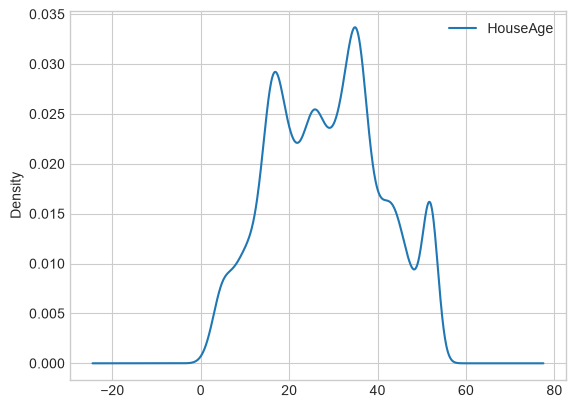

In [23]:
# Optional: Create plots here
pandas_data[["HouseAge"]].plot.density()
plt.show()

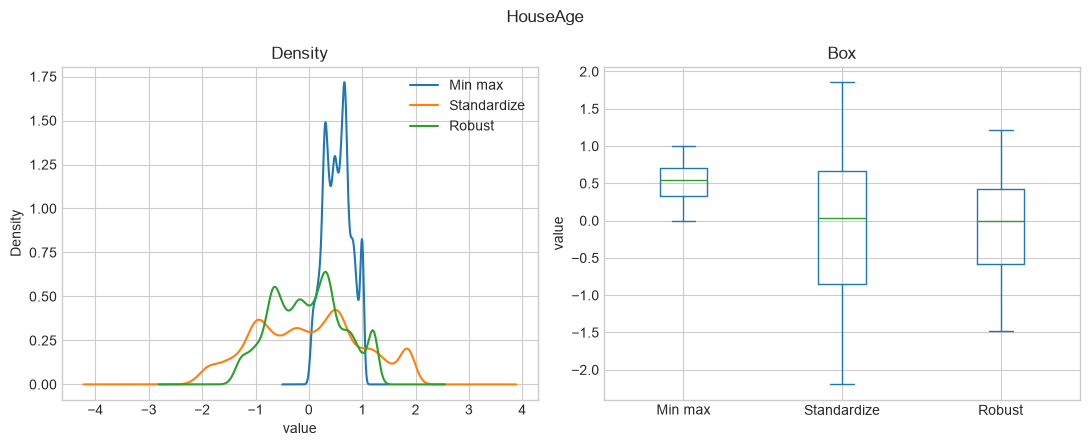

In [24]:
def plot_all_normals(df, feature_name):
    data_in = df[[feature_name]].to_numpy()
    df_out = pd.DataFrame()
    funcs = [norm_min_max, norm_standard, norm_robust]
    names = ["Min max", "Standardize", "Robust"]
    for func, name in zip(funcs, names):
        df_out[name] = func(data_in).ravel()   # ravel -> 1D

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.suptitle(feature_name)

    df_out.plot.density(ax=axes[0], title="Density")
    axes[0].set_xlabel("value")

    df_out.plot.box(ax=axes[1], title="Box")
    axes[1].set_ylabel("value")

    plt.tight_layout()
    plt.show()


plot_all_normals(pandas_data, "HouseAge")

## 3. Optimization using gradient descent

In the previous section we looked at our dataset and normalized the data using different methods.
Now we take a step back and look at optimization.

Optimization is the process we will use to train our statistical models.
Here you will implement gradient descent, a classic optimization algorithm. 
It forms the basis of many modern approaches to machine learning, including the training of neural networks. 

You will first implement gradient descent to find minima on a mathematical function $f$. 
This should provide some intuition on how the process of optimization works in mathematical terms. 

In a later exercise you will use the same principles of optimization to build a model that predicts the median prices of homes in California.


### Task

Take a look at the following function $f(x, y)$:

$$f(x,y) = (x^2-1)^2 + \tfrac{1}{8}x + y^2 + \tfrac{1}{2}xy$$

The function describes a double well.
Luckily we can visualize it, because the output depends on two parameters.

In [25]:
# Define the double well function using numpy
def f(x: np.ndarray, y: np.ndarray):
    return np.square(np.square(x) - 1) + 0.125*x + np.square(y) + 0.5*x*y

In [26]:
def plot_func(paths=None, labels=None, points=None, title=None):
    # Create a range of values to evaluate the function
    lin_x = np.linspace(-2, 2, 100)
    lin_y = np.linspace(-1.5, 1.5, 100)
    x, y = np.meshgrid(lin_x, lin_y)
    
    # If you do not use meshgrid, the function only evaluates the diagonal [0, 0], [1, 1], etc
    # You can see this by uncommenting the following code and comparing the shapes of the numpy arrays
    # print(lin_x.shape, lin_y.shape)
    # print(x.shape, y.shape)
    
    # Evaluate the function on all grid coordinate combinations
    z = f(x, y)
    
    # Now create two plots next to each other to visualize the function
    fig = plt.figure(figsize=(13, 5.5))
    
    ax = fig.add_subplot(1, 2, 1, projection="3d")
    ax.plot_surface(x, y, z, cmap="viridis", linewidth=0, antialiased=True,
                    rstride=2, cstride=2)
    ax.set_zlim(z.min() - 0.3, 9.0)
    ax.view_init(elev=34, azim=-72)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("f(x, y)")
    ax.set_title("Surface plot, isometric view")
    
    ax2 = fig.add_subplot(1, 2, 2)
    cs = ax2.contourf(x, y, z, levels=35, cmap="viridis")
    ax2.contour(x, y, z, levels=35, colors="white", linewidths=0.4, alpha=0.5)
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    ax2.set_title("Contour plot, top view")
    fig.colorbar(cs, ax=ax2)

    if title:
        fig.suptitle(title)
        
    fig.tight_layout()

    # Draw paths if they are given
    if paths:
        colors = plt.cm.autumn(np.linspace(0.3, 0.9, len(paths)))
        if labels:
            # If labels are provided, check if we have all of them
            assert len(labels) == len(paths)
        
        for path, label, color in zip(paths, labels, colors):        
            ax.plot(path[:, 0], path[:, 1], path[:, 2] + 0.15,
                color=color, linewidth=2, label=label)
            ax2.plot(path[:, 0], path[:, 1], color=color, linewidth=2, label=label)
            ax2.plot(path[0, 0], path[0, 1], "o", color=color, markeredgecolor="black")
        ax2.legend(loc="upper right", fontsize=8)

    if points:
        for point in points:
            ax.plot(point[0], point[1], "x", markeredgecolor="red")
            ax2.plot(point[0], point[1], "x", markeredgecolor="red")

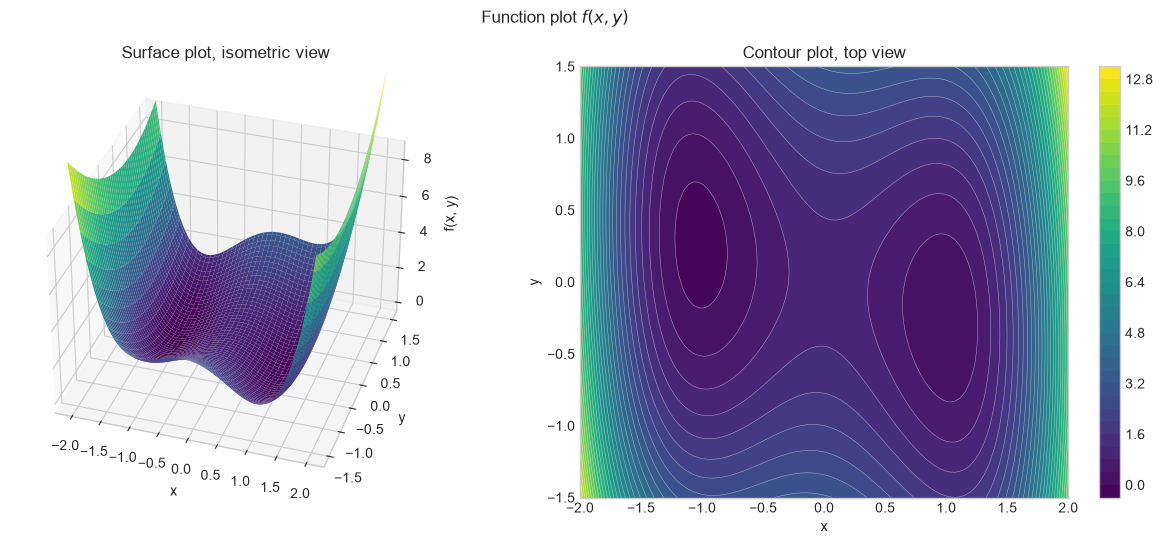

In [27]:
plot_func(title=r"Function plot $f(x,y)$")
plt.show()

This function has 2 minima, and is non-convex. 
You are going to implement gradient descent in order to find the minimum of this function, given some pre-determined starting positions.
If all goes well you should be able to find the two local minima using gradient descent by the end of this part of the assignment.

### 3a. Calculating the gradient

As a first step, write a function `grad_f` that returns the gradient $\nabla f(x, y)$ by calculating the partial gradients analytically.

__Task:__ Write the gradients of the locations specified in the setup code in ANS.

In [28]:
question_x_coords = [1.25, 3]
question_y_coords = [0, 0]

In [29]:
# TODO: Implement the gradient method
def grad_f(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    grad_x = 4 * x * (x**2 - 1) + 0.125 + 0.5 * y
    grad_y = 2 * y + 0.5 * x
    return np.array([grad_x, grad_y])

In [30]:
print("3a. Calculating the gradient")
for x, y in zip(question_x_coords, question_y_coords):
    print(f"\tCoordinates x: {x}, y: {y}, grad: {grad_f(x, y)}")

3a. Calculating the gradient
	Coordinates x: 1.25, y: 0, grad: [2.9375 0.625 ]
	Coordinates x: 3, y: 0, grad: [96.125  1.5  ]


### 3b. Derive the critical points

Gradient descent can only come to rest where the gradient is zero. Such a point is called a critical point, and it can be a minimum, a maximum, or a saddle. For this function you can find all critical points analytically, so you can check your optimizer against an exact answer later.

__Task:__

1. Compute both partial derivatives of $f$. Set $\partial f/\partial y = 0$ and solve it for $y$ in terms of $x$.
2. Express the equation in terms of $px^3 + qx^2 + rx + s = 0$, and factor out such that $p=1$.
3. For each root, compute the coordinates $(x, y)$ by using `np.roots`. Write all $(x, y)$ pairs to `ANS`.

_Optional:_ Add the points as markers on your contour plot of $f$ for a visual check. Substitute each point back into both partial derivatives and confirm they are zero up to rounding error.

In [31]:
# TODO: Find the correct points.
# The three pairs below show the format only. They are not the answer.
#points = [[0.3, 0.0], [1.0, 0.4], [-0.5, 0.2]]
p = 1
q = 0
r = -33 / 32
s = 1 / 32

x_values = np.roots([p, q, r, s])

points = []
for x in x_values:
    y = -x / 4
    points.append([float(x), float(y)])

3b. Derive the critical points
	Critical point (x, y): [-1.0303300858899107, 0.2575825214724777] with value -0.19134790912614946
	Critical point (x, y): [1.0, -0.25] with value 0.0625
	Critical point (x, y): [0.030330085889910638, -0.0075825214724776595] with value 1.0018947841261494


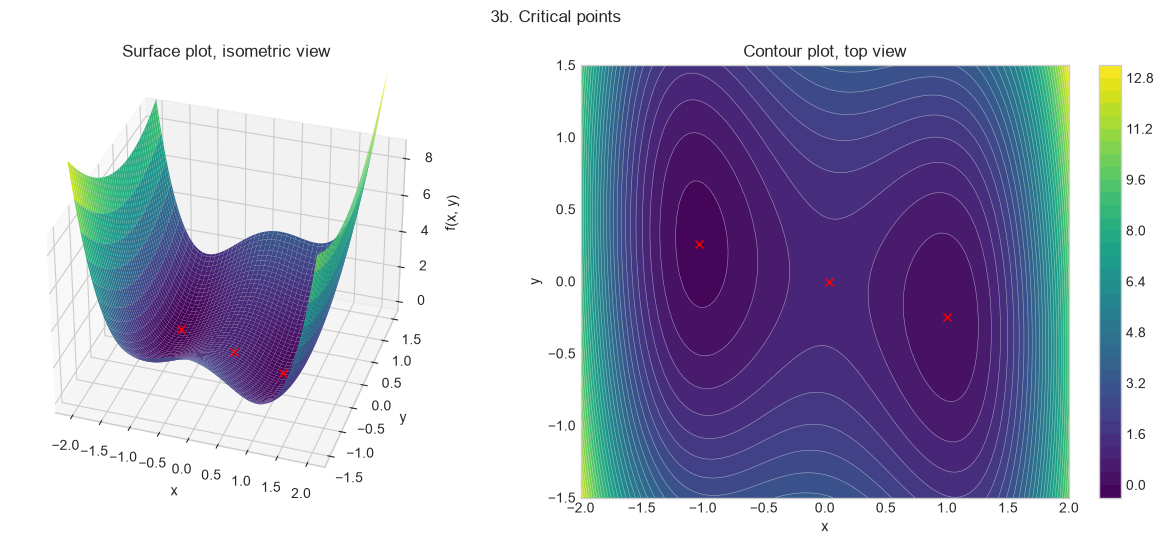

In [32]:
print("3b. Derive the critical points")
for point in points:
    print(f"\tCritical point (x, y): {point} with value {f(point[0], point[1])}")

plot_func(title=r"3b. Critical points", points=points)
plt.show()

### 3c. Gradient update

Now write the gradient descent python method called `gradient_descent`. 
The method should take the python methods `f` and `grad_f`, a constant update rate `eta_const`, starting position `x_start, y_start` and a maximum amount of update steps called `max_steps`.
It should return the entire _trajectory_ of the gradient descent, so every `x` and `y` position, and the value of `f` at that point in the trajectory.

Every update step moves the position against the gradient you derived in 3a:

$$x \leftarrow x - \eta \frac{\partial f}{\partial x}, \qquad y \leftarrow y - \eta \frac{\partial f}{\partial y}$$

Consider plotting the starting positions, trajectories and final positions if you want to check if you implemented gradient descent correctly.
Compare with the analytical solution you computed previously.

__Task:__ Write the position of the gradient descent, and the function value at that point, after `q_num_steps_3c` update steps to ANS. 
The initial position should be recorded as `path[0]`.

In [35]:
q_x_start = [-1, -1.5, 1.8]
q_y_start = [-1, 1, 0]
q_num_steps_3c = 3  # Check the third position for the answer
q_eta_3c = 4e-2
max_steps_3c = 1000

In [36]:
# TODO: Implement the gradient_descent method
def gradient_descent(f: Callable, 
                     grad_f: Callable,
                     eta_const: float,
                     x_start: float,
                     y_start: float,
                     max_steps: int) -> np.ndarray: 
    path = np.empty((max_steps + 1, 3), dtype=np.float64)
    x, y, eta = float(x_start), float(y_start), float(eta_const)
    path[0] = (x, y, f(x, y))
    # Implement here
    for t in range(max_steps):
        
        gradient = grad_f(x, y)

        x = x - eta * gradient[0]
        y = y - eta * gradient[1]

        path[t + 1] = (x, y, f(x, y))
    return path

3c. Gradient update
	Start x: -1, y: -1, eta: 0.04: 
		Values after 3 steps x: -0.9727261989465301, y: -0.7241021492, f(x, y): 0.7578045558685238
	Start x: -1.5, y: 1, eta: 0.04: 
		Values after 3 steps x: -1.114090437848441, y: 0.84963755, f(x, y): 0.1675123623866422
	Start x: 1.8, y: 0, eta: 0.04: 
		Values after 3 steps x: 1.051138694793291, y: -0.07335453136102954, f(x, y): 0.1092227791839001


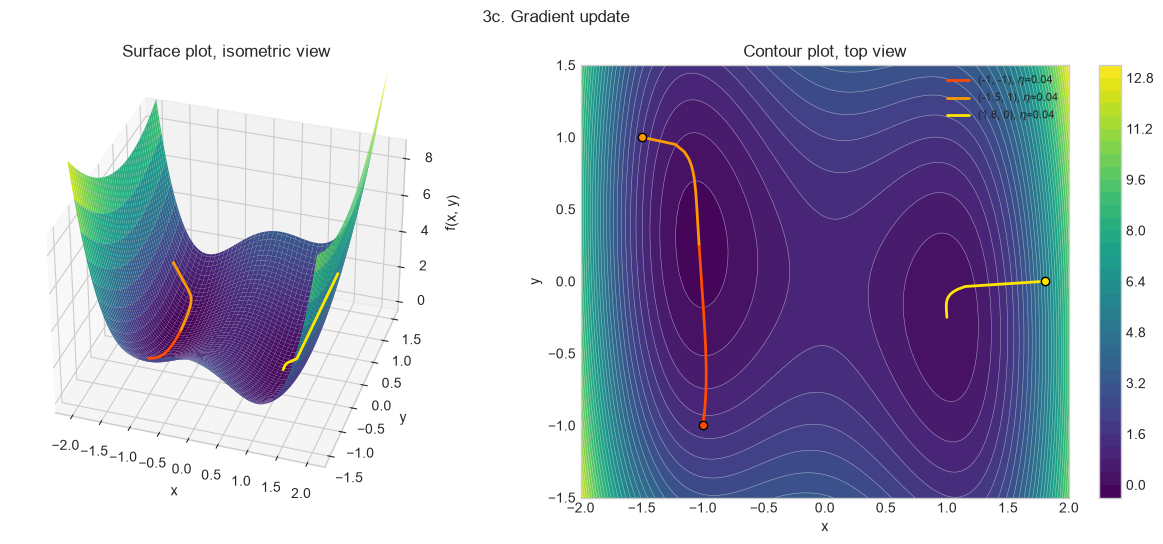

In [37]:
paths = []
labels = []
print("3c. Gradient update")
for x, y in zip(q_x_start, q_y_start):
    path = gradient_descent(f, grad_f, q_eta_3c, x, y, max_steps_3c)
    print(f"\tStart x: {x}, y: {y}, eta: {q_eta_3c}: ")
    print(f"\t\tValues after {q_num_steps_3c} steps x: {path[q_num_steps_3c, 0]}, y: {path[q_num_steps_3c, 1]}, f(x, y): {path[q_num_steps_3c, 2]}")
    paths.append(path)
    labels.append(f"({x}, {y}), $\\eta$={q_eta_3c}")

plot_func(paths, labels, title="3c. Gradient update")
plt.show()

### 3d. Comparing step functions
The update step size does not have to be constant.
It can be any function of the step number `t`, which gives a whole family of gradient descent variants.
Here you will implement one of them.

Write a new method called `gradient_descent_sqrt`, which is a slight modification of the original `gradient_descent`.
Instead of a constant `eta`, it takes a constant `eta_c` and shrinks the step as the loop progresses.
Implement a method `eta_sqrt(t, c)`, where `t` is the current step in the gradient descent loop and `c` is `eta_c`, such that it returns a decreasing step size:

$$\eta_{sqrt} = c/\sqrt{t+1}$$

__Task:__ Write the position of `gradient_descent_sqrt`, and the function value at that point, after `q_num_steps_3d` update steps to ANS. 
The initial position should be recorded as `path[0]`. Try and visualize the result.

_Optional:_ Run `gradient_descent` from 3c and `gradient_descent_sqrt` with a step size constant of `0.2` and plot both sets of trajectories. See what the choice of step size does.


In [38]:
q_x_start = [-1, -1.5, 1.8]
q_y_start = [-1, 1, 0]
q_num_steps_3d = 3  # Check the third position for the answer
q_eta_c_sqrt = 4e-2
max_steps_3d = 2000

In [39]:
# TODO: Implement the eta_sqrt and gradient_descent_sqrt methods

# Decreasing step size (inverse sqrt)
def eta_sqrt(t, c):
    return c / np.sqrt(t + 1) # Implement here

def gradient_descent_sqrt(f: Callable, 
                     grad_f: Callable,
                     eta_c: float,
                     x_start: float,
                     y_start: float,
                     max_steps: int) -> np.ndarray: 
    path = np.empty((max_steps + 1, 3), dtype=np.float64)
    x, y = float(x_start), float(y_start)
    path[0] = (x, y, f(x, y))
    for t in range(max_steps):
        
        eta = eta_sqrt(t, eta_c)
        
        gradient = grad_f(x, y)
        
        x = x - eta * gradient[0]
        y = y - eta * gradient[1]
        
        path[t + 1] = (x, y, f(x, y))
    return path

3d Comparing step functions
	Start x: -1, y: -1, eta_c: 0.04: 
		Values after 3 steps x: -0.9761055617403509, y: -0.7852780280662098, f(x, y): 0.8801350446343953
	Start x: -1.5, y: 1, eta_c: 0.04: 
		Values after 3 steps x: -1.1454079484910997, y: 0.88492723718414, f(x, y): 0.23043752346954993
	Start x: 1.8, y: 0, eta_c: 0.04: 
		Values after 3 steps x: 1.0800823042387893, y: -0.060664165109395145, f(x, y): 0.13367744143918367


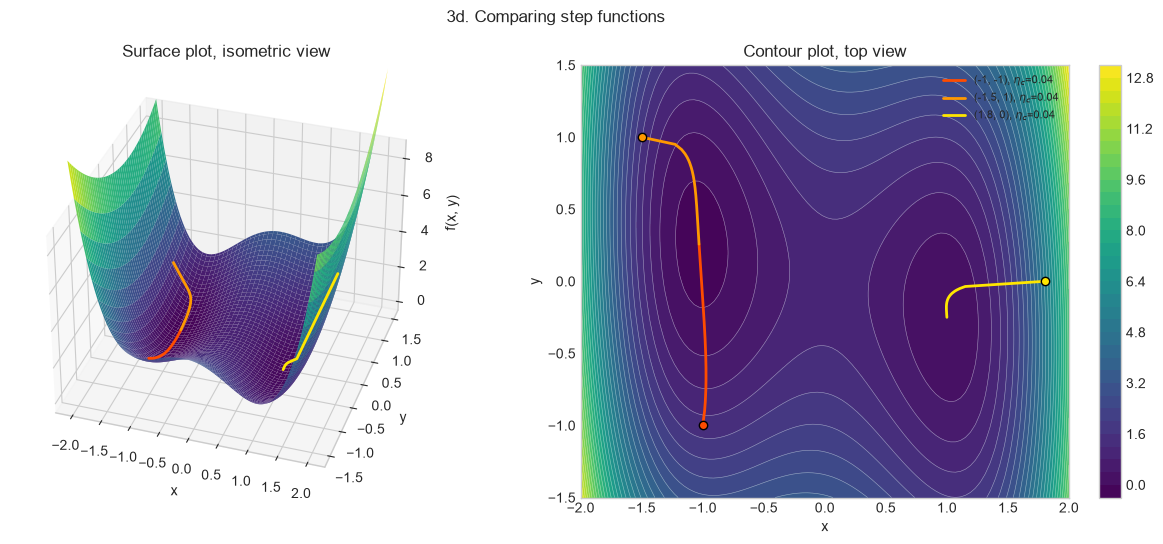

In [40]:
paths = []
labels = []
print("3d Comparing step functions")
for x, y in zip(q_x_start, q_y_start):
    path = gradient_descent_sqrt(f, grad_f, q_eta_c_sqrt, x, y, max_steps_3d)
    print(f"\tStart x: {x}, y: {y}, eta_c: {q_eta_c_sqrt}: ")
    print(f"\t\tValues after {q_num_steps_3d} steps x: {path[q_num_steps_3d, 0]}, y: {path[q_num_steps_3d, 1]}, f(x, y): {path[q_num_steps_3d, 2]}")
    paths.append(path)
    labels.append(f"({x}, {y}), $\\eta_c$={q_eta_c_sqrt}")

plot_func(paths, labels, title="3d. Comparing step functions")
plt.show()

## 4. Regression with gradient descent
You've implemented gradient descent yourself, from scratch, in the previous question.
Now you are going to use that knowledge to create a regression model, and train it with gradient descent.

Be careful. 
_Parameter optimization_ using gradient descent (here) is often confused with _searching for local minima of a function_ using gradient descent (previous exercise). 
We are going to take a look at the difference before moving to the implementation.

First assume that we are going to train a model $m$.
We choose a quadratic function to represent our model because we think it might fit the data well.
The model function thus becomes $m(x)=ax^2+bx+c$.
The variable $x$ represents the input data, and the parameters $a, b$ and $c$ are constants that we can use to tune the model. 

The difference between both uses of gradient descent is our _objective_.

__Previous exercise__

> Given $m(x)=ax^2 + bx + c$ with $a$, $b$ and $c$ some real number, find $x$ such that $m(x)$ is a minimum.

In the previous exercise we wanted to find minima of $m$.
The parameters $(a, b, c)$ are already known, and so we treat the function as fixed.
You calculated the value and the gradient of the function at a given point, and then stepped in the negative direction of that gradient. 
Do that enough times and with the proper settings and you will find a local minimum. 

__Current exercise__


> Given $m(x)=ax^2 + bx + c$ and some dataset $D$, find $a$, $b$ and $c$ such that the difference between the model and the data is minimal.

Here we do not treat the function $m$ as fixed! 
Rather, _we treat the data as fixed_, and try to tune function $m$ using the parameters $a, b, c$ to closely match the function to the data.

That means that "calculating the value of $m$ and the gradient, then stepping" does not make any sense! 
It will not help us find the parameters for our model. 

So, what should we do then? 
We need to find another function __that when minimized gives us the best values $a, b, c$ so $m$ fits the data__!
We call this function the loss function $L(a, b, c)$.
The lower the value of the loss, the better the model fit. 

A common choice of loss is the __mean squared error__ (MSE). For every data point $(x_i, y_i)$ in $D$ we take the difference between the prediction $m(x_i)$ and the observed value $y_i$, square it, and average over all $n$ points:

$$L(a, b, c) = \frac{1}{n} \sum_{i=1}^{n} \big(m(x_i) - y_i\big)^2 = \frac{1}{n} \sum_{i=1}^{n} \big(a x_i^2 + b x_i + c - y_i\big)^2$$

We square the differences so that errors above and below the data count equally, and we divide by $n$ so that the loss does not grow simply because the dataset is large. The loss is zero only when the model passes exactly through every data point, and it grows as the fit gets worse.

Look carefully at what $L$ depends on. The data $x_i$ and $y_i$ are fixed numbers that we read from $D$, so they are not variables of $L$. The variables are $a$, $b$ and $c$. In other words, $L$ is a function of three inputs, and we are back to a problem you already know how to solve:

> Given $L(a, b, c)$, find $a$, $b$ and $c$ such that $L$ is a minimum.

This is the same kind of question as the previous exercise, only asked about a different function. 
We can reuse the same procedure.
Evaluate $L$ at the current parameter values, compute the gradient of $L$ with respect to $a$, $b$ and $c$, and step in the negative gradient direction.

Each step changes $a$, $b$ and $c$ a little, which changes the shape of $m$, which lowers the loss. 
Repeat this enough times and the quadratic will settle into the shape that best matches the data.

Notice what differs between the two exercises:

|  | Previous exercise | Current exercise |
| --- | --- | --- |
| Function we minimize | $m$ | $L$ |
| Known | $a, b, c$ | the data $(x_i, y_i)$ |
| Unknown | $x$ | $a, b, c$ |
| Gradient with respect to | $x$ | $a, b, c$ |

The gradient descent algorithm itself does not change. What changes is the function you hand to it, and the variables it is allowed to move.


### 4a. Implementing MSE
In the next cells you will implement $m$, the loss $L$, and its gradient, and then run your gradient descent code on a toy dataset.
Start by taking a look at our toy dataset.

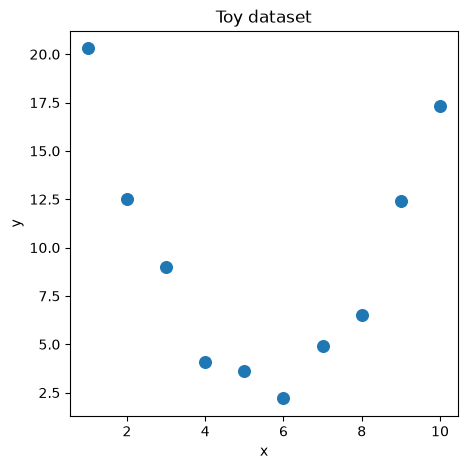

In [11]:
toy_data_x = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
toy_data_y = np.array([20.3, 12.5, 9.0, 4.1, 3.6, 2.2, 4.9, 6.5, 12.4, 17.3])

def plot_data(x, y, curves=None, labels=None, title="Toy dataset"):
    curves = curves if curves is not None else []
    colors = plt.cm.autumn(np.linspace(0.3, 0.9, len(curves)))

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(x, y, s=70, zorder=3, label="data")

    for i, (x_curve, y_curve) in enumerate(curves):
        label = labels[i] if labels is not None else None
        ax.plot(x_curve, y_curve, color=colors[i], linewidth=2.5,
                zorder=2 + i / len(curves), label=label)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    if labels is not None:
        ax.legend(fontsize=8, loc="upper center")
    return ax


plot_data(toy_data_x, toy_data_y)
plt.show()

__Task:__ Fit a quadratic model of the form $m(x) = ax^2 + bx + c$ through the dataset. 
Implement a Mean Squared Error (MSE) loss calculation in the code cell below.
Then tune $a$ by hand. 
You only need to tune up to two decimals. 
Do _not_ edit $b$ or $c$. Reduce the MSE to or below $0.5$. 
Report the MSE and the value for $a$.

In [12]:
par_b = -8.9751   # Already optimal. Do not edit.
par_c = 28.0617   # Already optimal. Do not edit.

curve_x = np.linspace(0, 11, 200)

In [13]:
# TODO: Implement the mse method and tune the value of a until the MSE requirement is satisfied.
#par_a = 0.0    # Tune this value
#par_a = 1.00 
#par_a = 0.80
#par_a = 0.75
par_a = 0.79


# Fit a parabola through the data
def m(x, a, b, c) -> np.ndarray:
    #pass # Implement
    return a * x**2 + b * x + c


# Calculate the mean squared error.
def mse(data_x, data_y, a, b, c) -> float:
    #pass # Implement
    predictions = m(data_x, a, b, c)
    
    residuals = predictions - data_y
    
    squared_errors = residuals**2
    
    return np.mean(squared_errors)

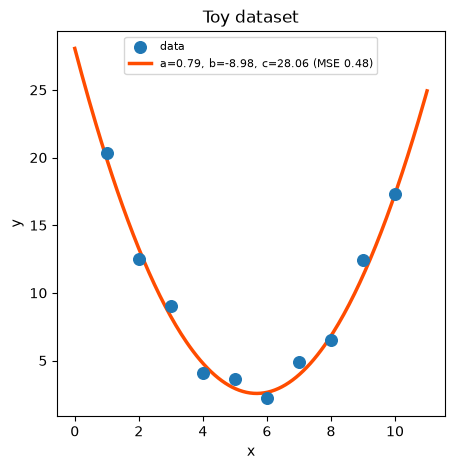

4a. Implementing MSE
	MSE: 0.47553690499999873, a: 0.79, b: -8.9751, c: 28.0617


In [14]:
curve_y = m(curve_x, par_a, par_b, par_c)
loss_value = mse(toy_data_x, toy_data_y, par_a, par_b, par_c)

plot_data(
    toy_data_x,
    toy_data_y,
    curves=[(curve_x, curve_y)],
    labels=[f"a={par_a:.2f}, b={par_b:.2f}, c={par_c:.2f} (MSE {loss_value:.2f})"],
)
plt.show()

print("4a. Implementing MSE")
print(f"\tMSE: {loss_value}, a: {par_a}, b: {par_b}, c: {par_c}")

### 4b. Partial derivatives
Derive the partial derivatives of the loss $L$ with respect to the model tuning parameters $a, b, c$:


$$\frac{\partial L}{\partial a}, \frac{\partial L}{\partial b} \text{ and } \frac{\partial L}{\partial c} $$


__Task:__ Implement methods for all three partial derivatives, evaluate them at the coordinates in the code below and report the loss for each. 

In [15]:
# Coordinates to evaluate at: (a, b, c)
coords = [
    (0.00,  0.00,  0.00),
    (0.79, -8.9751, 28.0617),   # the point you tuned in 4a
    (1.50, -5.00, 10.00),
]

In [16]:
# TODO: implement the three partial derivatives of the MSE loss.
# Each one takes the data and the current parameters, and returns a single number.

def dl_da(data_x, data_y, a, b, c) -> float:
    #pass # Implement here
    return np.mean(2 * (m(data_x, a, b, c) - data_y) * data_x**2)

def dl_db(data_x, data_y, a, b, c) -> float:
    #pass # Implement here
    return np.mean((2 * (m(data_x, a, b, c) - data_y) * data_x))
    
def dl_dc(data_x, data_y, a, b, c) -> float:
    return np.mean(2*(m(data_x,a,b,c) - data_y))

In [17]:
print("4b. Partial derivatives")
for a, b, c in coords:
    loss_value = mse(toy_data_x, toy_data_y, a, b, c)
    grad = (
        dl_da(toy_data_x, toy_data_y, a, b, c),
        dl_db(toy_data_x, toy_data_y, a, b, c),
        dl_dc(toy_data_x, toy_data_y, a, b, c),
    )
    print(f"\ta={a:.2f}, b={b:.2f}, c={c:.2f}")
    print(f"\t\tMSE:  {loss_value:.4f}")
    print(f"\t\tdL/da: {grad[0]:.4f}, dL/db: {grad[1]:.4f}, dL/dc: {grad[2]:.4f}")

4b. Partial derivatives
	a=0.00, b=0.00, c=0.00
		MSE:  120.3260
		dL/da: -755.3200, dL/db: -98.1600, dL/dc: -18.5600
	a=0.79, b=-8.98, c=28.06
		MSE:  0.4755
		dL/da: -21.8906, dL/db: -2.6140, dL/dc: -0.3327
	a=1.50, b=-5.00, c=10.00
		MSE:  2122.4710
		dL/da: 4589.5800, dL/db: 534.3400, dL/dc: 61.9400


### 4c. Gradient descent
Write the gradient descent implementation with a constant learning rate $\eta$ to optimize your model parameters $a, b, c$. 

__Task:__ Write the position of the gradient descent, and the function value at that point, after the number of update steps noted in the setup code to ANS. 
The initial position should be recorded as `path[0]`.
Do this for all the starting positions noted below.

_Optional:_ Plot the model curve at different optimization steps in the data plot to see how the model shapes up over time. 

In [18]:
q_a_start = [0.0]
q_b_start = [0.0]
q_c_start = [0.0]
q_num_steps_4c = 100_000  # Check this position for the answer
q_eta_4c = 3e-4
max_steps_4c = 100_000
snapshots = [0, 1000, 100_000]  # only used for the optional plot


# Wrap the loss and its gradient so they only depend on (a, b, c)
def loss_f(a: float, b: float, c: float) -> float:
    return mse(toy_data_x, toy_data_y, a, b, c)


def grad_loss_f(a: float, b: float, c: float) -> tuple:
    return (dl_da(toy_data_x, toy_data_y, a, b, c),
            dl_db(toy_data_x, toy_data_y, a, b, c),
            dl_dc(toy_data_x, toy_data_y, a, b, c))

In [23]:
# TODO: Implement the gradient descent method and report the coordinates and loss after a set amount of steps.
def gradient_descent_mse(loss: Callable,
                         grad_loss: Callable,
                         eta_const: float,
                         a_start: float,
                         b_start: float,
                         c_start: float,
                         max_steps: int) -> np.ndarray:
    path = np.empty((max_steps + 1, 4), dtype=np.float64)
    a, b, c, eta = float(a_start), float(b_start), float(c_start), float(eta_const)
    path[0] = (a, b, c, loss(a, b, c))
    # Implement here
    
    for t in range(max_steps):
        
        gradient = grad_loss(a, b, c)
        
        a = a - eta * gradient[0]
        b = b - eta * gradient[1]
        c = c - eta * gradient[2]
        
        path[t + 1] = (a, b, c, loss(a, b, c))
    return path

4c. Gradient descent
	Start a: 0.0, b: 0.0, c: 0.0, eta: 0.0003: 
		Values after 100000 steps a: 0.7746141697725627, b: -8.73011215075528, c: 27.433444404391082, L(a, b, c): 0.4568786383309048


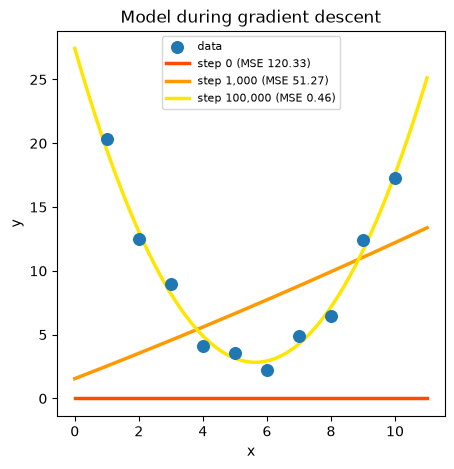

In [24]:
paths = []
labels = []
print("4c. Gradient descent")
for a, b, c in zip(q_a_start, q_b_start, q_c_start):
    path = gradient_descent_mse(loss_f, grad_loss_f, q_eta_4c, a, b, c, max_steps_4c)
    print(f"\tStart a: {a}, b: {b}, c: {c}, eta: {q_eta_4c}: ")
    print(f"\t\tValues after {q_num_steps_4c} steps a: {path[q_num_steps_4c, 0]}, b: {path[q_num_steps_4c, 1]}, c: {path[q_num_steps_4c, 2]}, L(a, b, c): {path[q_num_steps_4c, 3]}")
    paths.append(path)
    labels.append(f"({a}, {b}, {c}), $\\eta$={q_eta_4c}")

# Optional: watch the model take shape.
curves = []
curve_labels = []
for step in snapshots:
    a, b, c, step_loss = paths[0][step]
    curves.append((curve_x, m(curve_x, a, b, c)))
    curve_labels.append(f"step {step:,} (MSE {step_loss:.2f})")

plot_data(toy_data_x, toy_data_y, curves=curves, labels=curve_labels,
          title="Model during gradient descent")
plt.show()

## 5. Bias and variance

Once you derive a model from data you will likely want to put it to use.
But how do you know if the predictions of your new model are accurate?
One important factor is the training data.
If you try to predict a value far outside the training data you will likely get bad results, because the model loss for similar situations has not been computed during training.
Another is choosing the correct model type, or shape, with respect to your data.
The concepts of _bias_ and _variance_ can help to determine the tradeoffs you face when choosing one yourself. 


### Task

In this exercise you will explore the concepts of _bias_ and _variance_ as they relate to choosing the correct model type to fit your dataset.
You will calculate bias and variance for several "model classes" and compare them in order to build intuition about the possible sources of prediction error in regression models.




### Theory

Bias and variance are not properties of a single model, but rather of the entire fitting procedure.
They tell you how a set of models, say $\hat{f}_1, \hat{f}_2 ... \hat{f}_k$, relate to a real, "ground truth", data function $f$. 

Each model in that set is fitted on its own measured dataset.
Because every dataset is measured separately, the models differ from each other.
We can average the predictions of all the models as $\overline{f}$

$$\overline{f}(x) = \frac{1}{k} \sum_{i=1}^{k} \hat{f}_i(x)$$

The __bias__ is the difference between that average prediction and the truth.
It tells you whether the model shape you chose can represent $f$ at all.
For example, if you try to fit a curve with a straight line model you will always have a high bias, regardless of the orientation of the line.

$$\text{bias}(x) = \overline{f}(x) - f(x)$$

The __variance__ is how far the individual models sit from their own average.
It tells you how much the procedure reacts to the particular dataset it happened to receive.
A flexible model that crosses every measured point produces a very different function depending on the precise data points you sample, and so has a high variance.

$$\text{var}(x) = \frac{1}{k} \sum_{i=1}^{k} \left( \hat{f}_i(x) - \overline{f}(x) \right)^2$$

Both feed into the error you observe when you use your model and compare to the ground truth.
Making a model more flexible generally lowers the bias but raises the variance, and making it simpler generally does the opposite.



### Example

Let us consider a concrete example for this assignment. 

Assume a dataset
$$D_\text{real} = \{(x_i, y_i)\}_{i=1}^{n}$$

It is a set of tuples, where $x$ indicates the feature (input) and $y$ the target (output), and has $n$ number of samples.

The data is sampled from an underlying "ground truth" function $f$. 
For the purpose of this exercise, i.e. to build some intuition on the bias later, we assume we know it exactly, although in practice this is almost never the case.
The function is defined as:

$$
f(x) = \frac{1}{e^{-\lambda x}} \sin{x} 
$$

The ground truth function $f$ is an amplified sinusoid, with $\lambda$ determining the amplification. 

$D_\text{real}$ reflects all the possible data we could measure, if we measured perfectly.

Visually the dataset looks like this:

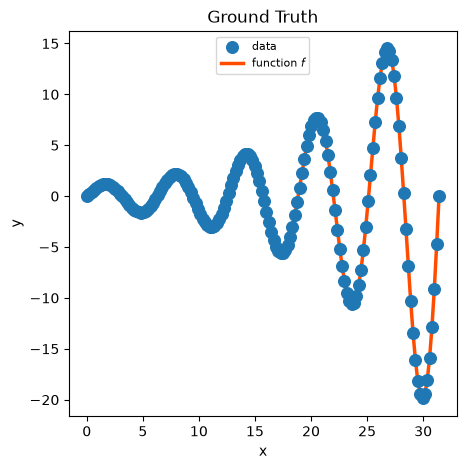

In [25]:
# Generate data from an amplified sinusoid

def sin_amp(x, lam):
    return 1/np.exp(-lam * x) * np.sin(x)

n_points = 150
lam = 0.1
bv_data_x = np.linspace(0, 10 * np.pi, n_points)
bv_data_y = sin_amp(bv_data_x, lam)

plot_data(bv_data_x, bv_data_y, curves=[[bv_data_x, bv_data_y]], labels=["function $f$"], title="Ground Truth")
plt.show()

When we actually measure data, we usually introduce two sources of error. Firstly we might miss some samples during measurement, and secondly our measurement devices and methods contain errors. Let's say three different people measured $D_\text{real}$, and each produced a sampled dataset $S_k$ with $k \in \{1,2,3\}$:

$$S_k = \{(x_i,\; y_i + \varepsilon_i) \;:\; i \in I_k\}, \qquad \varepsilon_i \overset{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2)$$

where $I_k \subseteq \{1, \dots, n\}$ is the subset of points that person $k$ sampled, and $\varepsilon_i$ is the noise their measurement added through measurement error. We can visualize that as well.

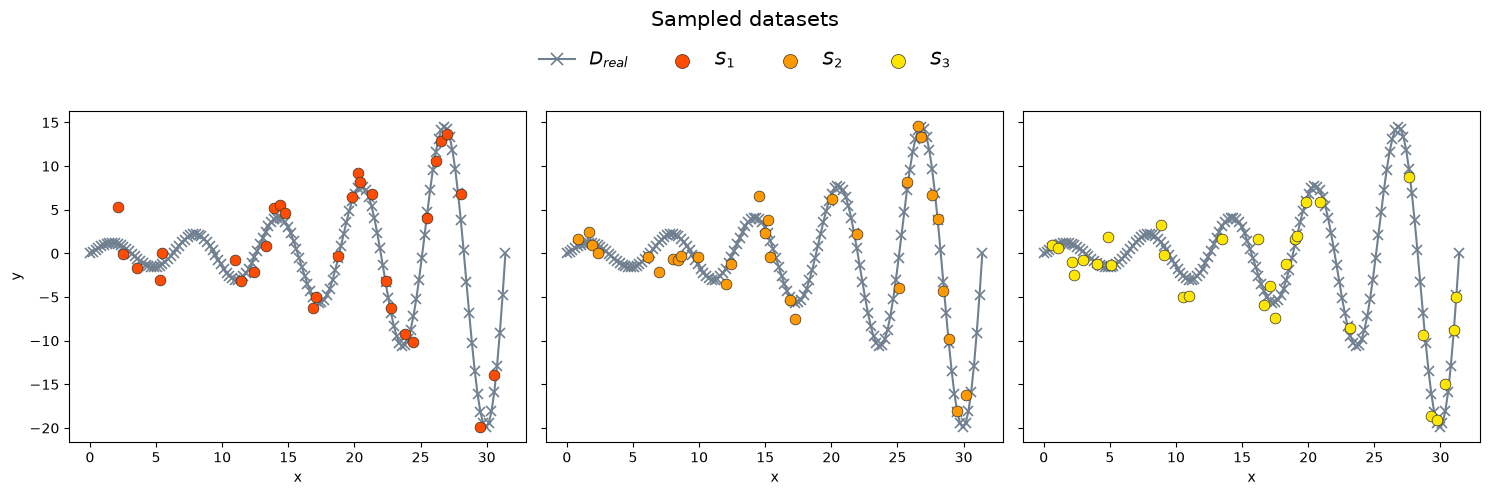

In [26]:
# The three sampled datasets, frozen so the graded answers cannot drift.
# See the teacher cell below to regenerate them.
samples = [
    # S_1
    (np.array([   2.1085,    2.5301,    3.5844,    5.2711,    5.4820,
                 10.9639,   11.3856,   12.4399,   13.2832,   13.9158,
                 14.3375,   14.7592,   16.8676,   17.0785,   18.7652,
                 19.8194,   20.2411,   20.4520,   21.2954,   22.3496,
                 22.7713,   23.8255,   24.4580,   25.5123,   26.1448,
                 26.5665,   26.9882,   28.0424,   29.5183,   30.5725]),
     np.array([   5.3438,   -0.0735,   -1.6376,   -3.0640,   -0.0106,
                 -0.7339,   -3.1156,   -2.1180,    0.8311,    5.2242,
                  5.5970,    4.6420,   -6.2828,   -4.9424,   -0.3168,
                  6.4230,    9.1910,    8.1740,    6.7492,   -3.1436,
                 -6.2787,   -9.1959,  -10.1229,    4.1112,   10.6420,
                 12.8371,   13.7139,    6.7858,  -19.8595,  -13.9492])),
    # S_2
    (np.array([   0.8434,    1.6868,    1.8976,    2.3193,    6.1145,
                  6.9579,    8.0121,    8.4338,    8.6447,    9.9097,
                 12.0182,   12.4399,   14.5483,   14.9700,   15.1809,
                 15.3917,   16.8676,   17.2893,   20.0303,   21.9279,
                 25.0906,   25.7231,   26.5665,   26.7773,   27.6207,
                 28.0424,   28.4641,   28.8858,   29.5183,   30.1509]),
     np.array([   1.7057,    2.5066,    0.9480,    0.0774,   -0.4689,
                 -2.1220,   -0.6938,   -0.7011,   -0.3249,   -0.4562,
                 -3.5444,   -1.1941,    6.5252,    2.2936,    3.7706,
                 -0.4177,   -5.3626,   -7.5344,    6.1767,    2.2470,
                 -3.9729,    8.1590,   14.5903,   13.3242,    6.7351,
                  3.9402,   -4.3082,   -9.8491,  -18.0842,  -16.2417])),
    # S_3
    (np.array([   0.6325,    1.0542,    2.1085,    2.3193,    2.9518,
                  4.0061,    4.8494,    5.0603,    8.8555,    9.0663,
                 10.5423,   10.9639,   13.4941,   16.2351,   16.6568,
                 17.0785,   17.5001,   18.3435,   18.9761,   19.1869,
                 19.8194,   20.8737,   23.1930,   27.6207,   28.6749,
                 29.3075,   29.7292,   30.3617,   30.9942,   31.2051]),
     np.array([   0.9439,    0.6489,   -1.0108,   -2.4254,   -0.7192,
                 -1.2432,    1.9270,   -1.2988,    3.2723,   -0.1300,
                 -4.9498,   -4.9221,    1.6346,    1.7061,   -5.9414,
                 -3.7298,   -7.4201,   -1.1716,    1.6114,    1.9414,
                  5.9041,    5.9396,   -8.5920,    8.7173,   -9.3120,
                -18.6533,  -19.0724,  -14.9498,   -8.7605,   -4.9793])),
]

# Plot the samples side by side with respect to the original data
def plot_samples(x, y, samples, labels=None, title="Sampled datasets"):
    colors = plt.cm.autumn(np.linspace(0.3, 0.9, len(samples)))
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5),
                             sharex=True, sharey=True, squeeze=False)
    axes = axes[0]
    handles = []
    for i, ((x_s, y_s), ax) in enumerate(zip(samples, axes)):
        h_real, = ax.plot(x, y, marker="x", color="slategray",
                          markersize=7, markeredgewidth=1.2, zorder=1,
                          label="$D_{real}$")
        h = ax.scatter(x_s, y_s, s=60, color=colors[i], edgecolor="0.2",
                       linewidth=0.5, zorder=3,
                       label=labels[i] if labels is not None else f"$S_{i+1}$")
        handles.append(h)
        ax.set_xlabel("x")
    axes[0].set_ylabel("y")
    fig.suptitle(title, fontsize=15)
    fig.legend([h_real] + handles, [h.get_label() for h in [h_real] + handles],
               loc="upper center", bbox_to_anchor=(0.5, 0.93),
               ncol=len(samples) + 1, fontsize=13, markerscale=1.3,
               frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.88])
    return axes

plot_samples(bv_data_x, bv_data_y, samples)
plt.show()

Notice that the data points on the y-axis are somewhat shifted according to the noise for each dataset, and that each set has different points which suggest a slightly different underlying model. 

For each of the sampled data set points you can run regression to get a linear model 

$$
\hat{f}(x) = ax + b
$$

If you would do so for the current example you might end up with the following three models

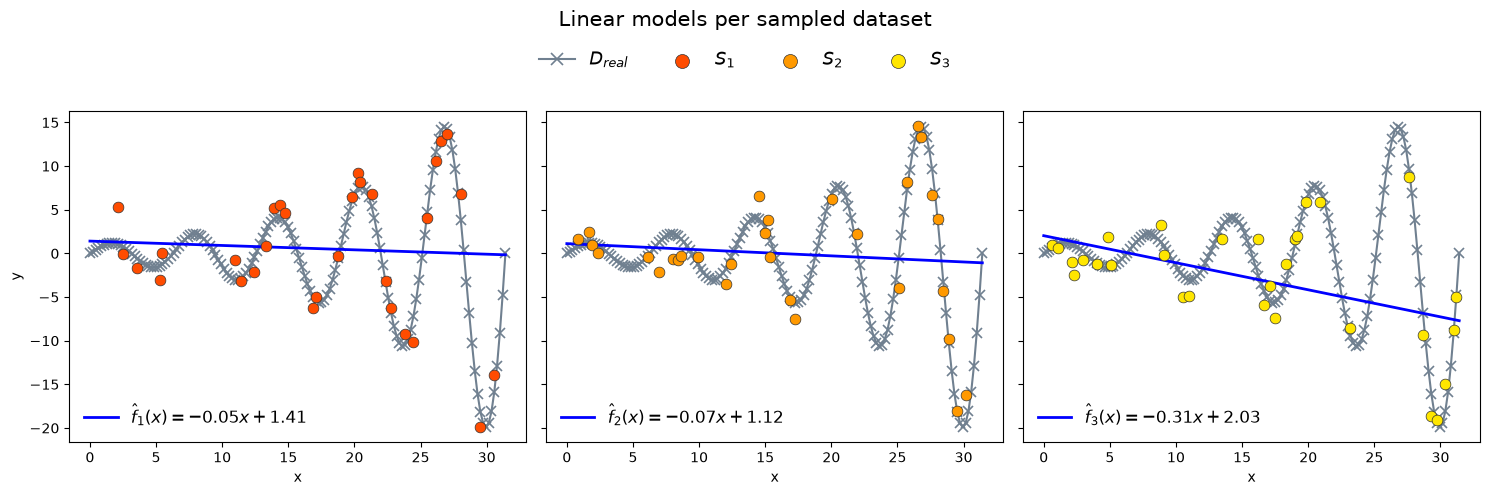

In [27]:
# The three models recovered from the sampled datasets above.
fits = [(-0.05, 1.41), (-0.07, 1.12), (-0.31, 2.03)]

def plot_fits(x, y, samples, fits, title="Linear models per sampled dataset"):
    axes = plot_samples(x, y, samples, title=title)
    x_line = np.linspace(x.min(), x.max(), 200)
    for i, ((a, b), ax) in enumerate(zip(fits, axes), start=1):
        h_fit, = ax.plot(x_line, a * x_line + b, color="blue", linewidth=2, zorder=1,
                         label=f"$\\hat{{f}}_{i}(x) = {a:.2f}x {b:+.2f}$")
        ax.legend(handles=[h_fit], loc="lower left", fontsize=12, frameon=False)
    return axes

plot_fits(bv_data_x, bv_data_y, samples, fits)
plt.show()

Each linear model has a different fit depending on the sampled data. 

### 5a. Calculating bias and variance

__Task:__ Write the three model functions $\{\hat{f}_1, \hat{f}_2, \hat{f}_3\}$ yourself, using the coefficients shown in the plot above.
Then calculate the bias and variance on the point $x_0=10$ for that set of models with respect to the ground truth $f$. Enter the bias and the variance in ANS.

In [28]:
# The point to evaluate at
x0 = 10

In [29]:
# TODO: Write the three model functions from the plot above, then evaluate them
# and the ground truth at x0 to calculate the bias and the variance.
def f_hat_1(x: np.ndarray) -> np.ndarray:
    return -0.05 * x + 1.41

def f_hat_2(x: np.ndarray) -> np.ndarray:
    return -0.07 * x +1.12

def f_hat_3(x: np.ndarray) -> np.ndarray:
    return -0.31 * x + 2.03

models = [f_hat_1, f_hat_2, f_hat_3]

predictions = np.array([model(x0) for model in models])
mean_prediction = np.mean(predictions)
value = sin_amp(x0, lam)

bias = mean_prediction - value
variance = np.var(predictions)

In [30]:
print("5a. Calculating Bias and Variance")
print(f"\tbias: {bias}, variance: {variance}")

5a. Calculating Bias and Variance
	bias: 1.5654693666953436, variance: 0.7089555555555558


### Visualizing bias and variance

A short intermezzo to understand bias and variance visually.
You can think of bias and variance in terms of a "dart board".
Say you evaluate the bias and variance at some data point $x_0$.

The "bullseye" would be the value returned by the ground truth function $f$.
Bias is the distance between the "bullseye" and the predictions of the model functions on average.
Variance then is the "spread" between the outer most points.
You can see this in the left most panel of the following graph.

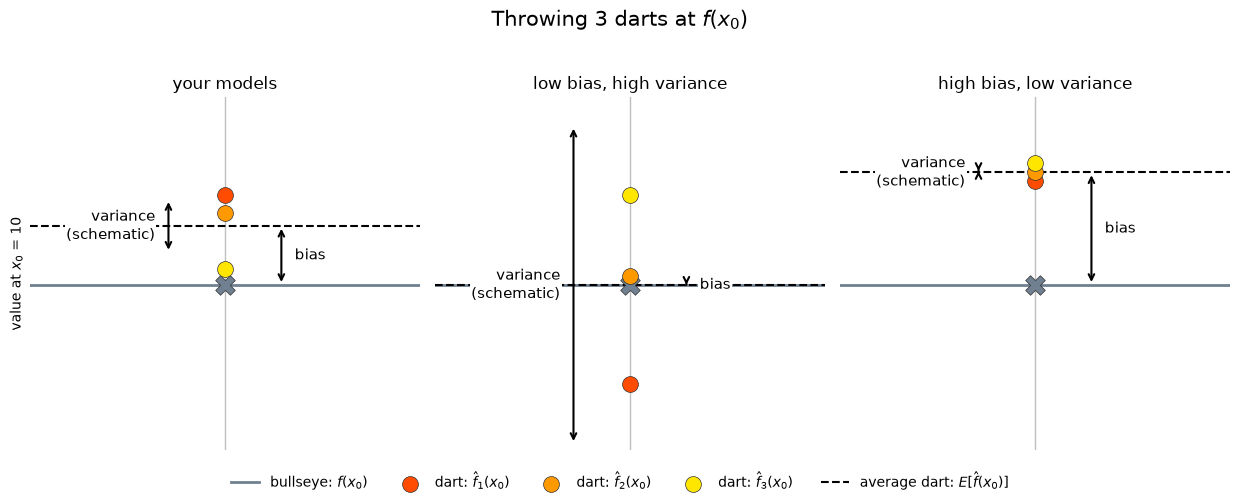

In [34]:
def draw_dartboard(ax, f_true, predictions, title, labelled=False):
    colors = plt.cm.autumn(np.linspace(0.3, 0.9, len(predictions)))
    mean_pred = predictions.mean()
    variance = predictions.var()

    ax.axvline(0, color="0.75", linewidth=1, zorder=1)
    ax.axhline(f_true, color="slategray", linewidth=2, zorder=2,
               label="bullseye: $f(x_0)$" if labelled else None)
    ax.scatter(0, f_true, marker="X", s=200, color="slategray", edgecolor="0.2",
               linewidth=0.5, zorder=5)
    for i, (pred, c) in enumerate(zip(predictions, colors), start=1):
        ax.scatter(0, pred, s=130, color=c, edgecolor="0.2", linewidth=0.5, zorder=5,
                   label=f"dart: $\\hat{{f}}_{i}(x_0)$" if labelled else None)
    ax.axhline(mean_pred, color="black", linestyle="--", linewidth=1.5, zorder=3,
               label="average dart: $E[\\hat{f}(x_0)]$" if labelled else None)

    ax.annotate("", xy=(0.55, mean_pred), xytext=(0.55, f_true),
                arrowprops=dict(arrowstyle="<->", color="black", linewidth=1.5))
    ax.text(0.68, (mean_pred + f_true) / 2, "bias", ha="left", va="center", fontsize=11,
            bbox=dict(facecolor="white", edgecolor="none", pad=1))
    ax.annotate("", xy=(-0.55, mean_pred + variance), xytext=(-0.55, mean_pred - variance),
                arrowprops=dict(arrowstyle="<->", color="black", linewidth=1.5))
    ax.text(-0.68, mean_pred, "variance\n(schematic)", ha="right", va="center", fontsize=11,
            bbox=dict(facecolor="white", edgecolor="none", pad=1))

    ax.set_xlim(-1.9, 1.9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=12)
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(False)

def plot_data_estimates_bias_variance(x0, models, f):
    # Plot the true value of f, the estimates and show what the bias indicates, and what the variance indicates.
    f_true = f(x0)
    predictions = np.array([f_hat(x0) for f_hat in models])
    spread = max(np.abs(predictions - f_true).max(), 1e-6)
    scenarios = [
        (predictions, "your models"),
        (f_true + spread * np.array([-1.1, 0.1, 1.0]), "low bias, high variance"),
        (f_true + spread * np.array([1.15, 1.25, 1.35]), "high bias, low variance"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 5), sharey=True)
    for ax, (preds, title) in zip(axes, scenarios):
        draw_dartboard(ax, f_true, preds, title, labelled=(ax is axes[0]))

    all_vals = np.concatenate([p for p, _ in scenarios] + [[f_true]])
    pad = 0.3 * (all_vals.max() - all_vals.min())
    axes[0].set_ylim(all_vals.min() - pad, all_vals.max() + pad)
    axes[0].set_ylabel(f"value at $x_0$ = {x0}")
    fig.suptitle(f"Throwing {len(models)} darts at $f(x_0)$", fontsize=15)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=10, frameon=False)
    fig.tight_layout(rect=[0, 0.07, 1, 0.95])
    return axes

axes = plot_data_estimates_bias_variance(x0, models, lambda x: sin_amp(x, lam))
plt.show()

When we talk about "low bias, high variance" we mean that the center of the data points cluster closely near the ground truth.
Conversely, "high bias, low variance" means that the points cluster together, but the focus of that cluster is relatively far from the ground truth.
You might notice that __bias can only be calculated when you have access to the ground truth__, even though in practice the ground truth is almost never available. 
Variance can be calculated regardless.
Even though you might not be able to calculate the bias exactly you can still use your understanding of it to diagnose potential issues with your models.

## 6. Regression for the California housing dataset

Everything that you made in the earlier sections comes together here.
In section 2 you normalized one column of the housing data, and in section 4 you fitted a curve to ten toy data points.
Now you fit a model to more than 16,000 real data points.
The model predicts the median house price of a California district from eight input features.
We choose to use all the features available for this exercise for now.

A model that fits its training data well does not always predict well on new data.
In order to be able to check model performance on data you have not trained with, hold back part of the data in 6a, and look at it only in 6e.
The data used to train is usually called "training data" or the "training split".
The other data is often called the "test data" or "test split".

### The design matrix

As you did earlier you will first create a linear regression model.
It should predict the price of one housing district as a weighted sum of the features of that district.
It is one of the simplest models that can use all eight features at the same time.

We will write the problem in matrix format.
This helps with clarity when dealing with models that have many feature dimensions later.

First we need a generic description of a linear model that takes into account the number of input features we will use.
The model is a function $\hat{f}$.
It takes the $p$ features of a data point and returns one prediction:

$$\hat{f}(x) = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_p x_p$$

The weights $w$ are the adjustable parameters of the model, and $x_j$ represents the input feature $j = \{1, 2, ..., p\}$.

We can express the model at data point $i$ of the dataset as

$$\hat{y}_i = \hat{f}(x_i) = w_0 + w_1 x_{i, 1} + w_2 x_{i, 2} + \dots + w_p x_{i, p}$$

where $\hat{y}_i$ is the prediction of the model for data point $i$, and $x_{i, j}$ represents the value of one of the feature $j=\{1, 2 ... p\}$ for data point $i$.

The number of weights corresponds to the number of data features, plus an offset weight $w_0$.
The weight indicates how strongly that feature moves the price.

The other element we need in order to conveniently represent all the gradient calculations of our model is the __design matrix__ $X$

$$X \in \mathbb{R}^{n \times (p+1)}$$

The design matrix contains the data expressed in real numbers, with $n$ rows corresponding to the number of entries in the dataset, and $p+1$ columns corresponding to the number of weights in the model.
The first column corresponding to $w_0$ needs to be represented as a column vector with entries $1$. 
All other columns are represented by the features $x$ in the data. 
Each row of $X$ is one input to $\hat{f}$, with a 1 in front

$$X_{i} = (1,\; x_{i, 1},\; \dots,\; x_{i, p})$$

By defining $X$ this way we can index the design matrix when calculating model output for a row $i$ in the dataset

$$\hat{y}_i = \hat{f}(x_i) = X_i w = w_0 + w_1 x_{i, 1} + w_2 x_{i, 2} + \dots + w_p x_{i, p}$$

Conveniently we can also use the design matrix to compute all $n$ predictions in the training data at once

$$\hat{y} = Xw, \qquad X \in \mathbb{R}^{n \times (p+1)}, \qquad w \in \mathbb{R}^{p+1}$$

The vector $\hat{y}$ holds all $n$ predictions for all the data points in the training data.


| Symbol | Meaning |
| --- | --- |
| $n$ | Total number of rows in the data. |
| $p$ | Number of features. Here $p = 8$. |
| $i$ | The row number, selecting a data point from 1 to $n$. |
| $j$ | The column number, selecting a feature from 1 to $p$. |
| $x_{i,j}$ | The value of feature $j$ for district $i$. |
| $y_i$ | The true median price of district $i$. |
| $\hat{f}$ | The model. It turns one district into one prediction. |
| $\hat{y}_i$ | The price that the model predicts for district $i$. |
| $w_j$ | The weight of feature $j$. |
| $w_0$ | The offset weight of the model. |


### 6a. Calculating the design matrix

__Task:__ The setup code below marks every fifth district as test data. With that split:

- Compute the mean and the standard deviation of each feature using only the training data.
- Standardize both the training and the test features with those training statistics:

$$x_{\text{standardized}} = \frac{x - \mu}{\sigma}$$

- Build the design matrices `X_train` and `X_test`.
- Store the corresponding target values in `y_train` and `y_test`.

Report the shape of `X_train` and the first four values of row 4242 in `X_train` to ANS.
Use the Numpy default `ddof=0` for the standard deviation.

_Important:_ Do not calculate separate means and standard deviations for the test data. Always use the statistics computed from the training data.


In [39]:
# Every fifth district goes to the test set. 
# Normally randomly sampled, but fixed here for educational purposes.
row_index = np.arange(len(pandas_target))
is_test = row_index % 5 == 0
is_train = ~is_test

features_all = pandas_data.to_numpy()
target_all = pandas_target.to_numpy()

report_row = 4242

In [40]:
# TODO: standardize the features with the training statistics, then build the
# design matrix.
def standardize(x: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return (x - mean) / std


def build_design_matrix(x: np.ndarray) -> np.ndarray:
    ones = np.ones((x.shape[0], 1))
    return np.concatenate((ones, x), axis =1)

features_train = features_all[is_train]
features_test = features_all[is_test]

train_mean = np.mean(features_train, axis=0)
train_std = np.std(features_train, axis=0)

z_train = standardize(features_train, train_mean, train_std)
z_test = standardize(features_test, train_mean, train_std)

X_train = build_design_matrix(z_train)
X_test = build_design_matrix(z_test)

y_train = target_all[is_train]
y_test = target_all[is_test]

In [41]:
print("6a. The design matrix")
print(f"\tShape of X_train: {X_train.shape}")
print(f"\tShape of X_test: {X_test.shape}")
print(f"\tX_train[{report_row}, :4]: {X_train[report_row, :4]}")

6a. The design matrix
	Shape of X_train: (16512, 9)
	Shape of X_test: (4128, 9)
	X_train[4242, :4]: [1.         1.52045479 1.13583472 0.28549643]


### 6b. The loss and the gradient in matrix form

The next step is to define the loss function.
Again, this is a function that is smaller when model performance improves.
We can do something similar to using the mean squared error.

Calculate the residual vector that holds all $n$ prediction errors over the training data at the same time

$$r = Xw - y \in \mathbb{R}^n$$

Then square the errors and divide by the number of samples in the training data to arrive at the loss function

$$L(w) = \frac{1}{n}\|r\|^2 = \frac{1}{n} r^\top r$$

__Task:__ Derive $\nabla L(w)$. Implement `loss` and `grad_loss`.
Report the loss and the first four gradient values at the two weight vectors in the setup code.

In [42]:
# The weight vectors to evaluate at
w_zero = np.zeros(9)
w_guess = np.array([2.0, 0.8, 0.1, -0.2, 0.3, 0.0, 0.0, -0.9, -0.9])

report_gradient_values = 4

In [43]:
# TODO: Implement the loss and its gradient in matrix form.
def loss(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    #pass # Implement here
    r = X @ w - y
    return (r.T @ r) / len(y)


def grad_loss(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
    #pass # Implement here
    r = X @ w - y
    return (2 / len(y)) * (X.T @ r)

In [44]:
print("6b. The loss and the gradient in matrix form")
for name, w in [("w_zero", w_zero), ("w_guess", w_guess)]:
    print(f"\t{name}:")
    print(f"\t\tL(w): {loss(X_train, y_train, w)}")
    print(f"\t\tFirst {report_gradient_values} values of grad L(w): "
          f"{grad_loss(X_train, y_train, w)[:report_gradient_values]}")

6b. The loss and the gradient in matrix form
	w_zero:
		L(w): 5.6034626057459604
		First 4 values of grad L(w): [-4.13459419 -1.58632864 -0.24308324 -0.3434587 ]
	w_guess:
		L(w): 0.5342237048331347
		First 4 values of grad L(w): [-0.13459419 -0.00295266 -0.04413671  0.10021004]


### 6c. Training with gradient descent

You now have a loss and a gradient, so now you can implement gradient descent.

__Task:__ Write the loss after the maximum number of update steps noted in the setup code to ANS.
Write the weight vector after the last step as well.
The start position must be recorded as `path[0]`.

_Optional:_ Plot the loss against the step number. Use a logarithmic scale on both axes.

In [45]:
q_eta_6c = 5e-2
max_steps_6c = 10_000
q_report_steps_6c = [0, 1, 10, 100, 1000, 10_000]
w_start = np.zeros(9)

In [46]:
# TODO: Implement gradient descent for the weight vector w.
def gradient_descent_regression(X: np.ndarray,
                                y: np.ndarray,
                                eta_const: float,
                                w_start: np.ndarray,
                                max_steps: int) -> np.ndarray:
    path = np.empty((max_steps + 1, len(w_start) + 1), dtype=np.float64)
    w, eta = np.array(w_start, dtype=np.float64), float(eta_const)
    path[0] = np.append(w, loss(X, y, w))
    # Implement here
    for i in range(1, max_steps + 1):
        gradient = grad_loss(X, y, w)
        w = w- eta * gradient
        path[i] = np.append(w, loss(X, y, w))
    return path

In [47]:
print("6c. Training with gradient descent")
path_gd = gradient_descent_regression(X_train, y_train, q_eta_6c, w_start, max_steps_6c)
for step in q_report_steps_6c:
    print(f"\tStep {step}: L(w) = {path_gd[step, -1]}")
print(f"\tw after {max_steps_6c} steps: {path_gd[max_steps_6c, :-1]}")

6c. Training with gradient descent
	Step 0: L(w) = 5.6034626057459604
	Step 1: L(w) = 4.657382605249907
	Step 10: L(w) = 1.2395496439386595
	Step 100: L(w) = 0.552994409582341
	Step 1000: L(w) = 0.5239997114745636
	Step 10000: L(w) = 0.5239984048506414
	w after 10000 steps: [ 2.0672971   0.82146508  0.11867662 -0.25459213  0.30202264 -0.00421356
 -0.03923463 -0.90896518 -0.87616807]


### 6d. Normalization ablation

You created a model by this point and ran regression, but we told you to normalize your data before doing so.
In this exercise you will analyze the impact of normalization on the training process.
The code below will run three gradient descent runs: A normalized run and a raw run with the same update parameter, and a raw run with a very small update parameter.
Compare the runs.

__Task:__ Build a second design matrix from the raw features, without normalization.
Run three gradient descent runs as described above with `gradient_descent_regression`.
Report the loss after 10 steps of the standardized run and of the raw run with the small update parameter.
The loss of the raw run with the same update parameter is very large, so report its order of magnitude.
Answer the multiple choice question.

In [51]:
# The same settings as 6c, so the normalization is the only difference.
q_eta_compare = q_eta_6c
max_steps_compare = 20
q_report_step = 10

# A step size small enough to keep the raw features stable.
q_eta_raw_small = 2.5e-7
max_steps_raw_small = 50_000

In [52]:
# TODO: Build the design matrix from the raw features, without normalization.
# X_raw_train = None  # Implement here

# path_std = None # Implement here
# path_raw = None  # Implement here
# path_raw_small = None  # Implement here

X_raw_train = build_design_matrix(features_train)

path_std = gradient_descent_regression(X_train, y_train, q_eta_compare, w_start, max_steps_compare)
path_raw = gradient_descent_regression(X_raw_train, y_train, q_eta_compare, w_start, max_steps_compare)
path_raw_small = gradient_descent_regression(X_raw_train, y_train, q_eta_raw_small, w_start, max_steps_raw_small)

6d. Normalization ablation
	Losses:
		Standardized, loss after 10 steps: 1.2395496439386595
		Raw, loss after 10 steps: 3.85143e+110 (order of magnitude: 1e110)
		Raw with eta = 2.5e-07, loss after 10 steps: 2.8598761290629877


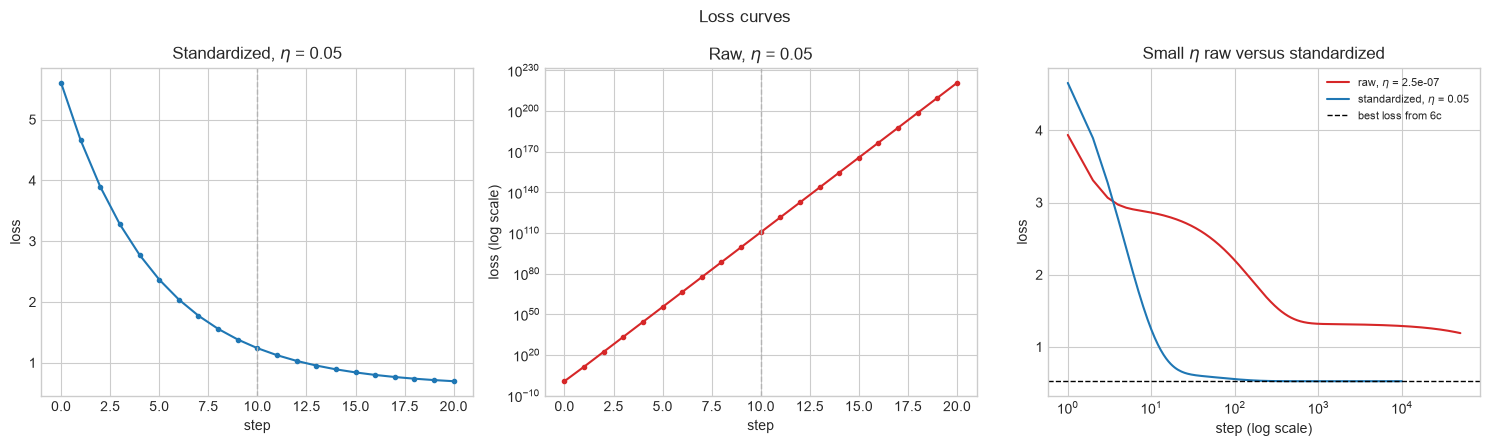

In [53]:
print("6d. Normalization ablation")

# The best loss your gradient descent reached in 6c, used here as a reference.
best_loss = path_gd[-1, -1]

print("\tLosses:")
print(f"\t\tStandardized, loss after {q_report_step} steps: {path_std[q_report_step, -1]}")
raw_loss = path_raw[q_report_step, -1]
print(f"\t\tRaw, loss after {q_report_step} steps: {raw_loss:.6g} "
      f"(order of magnitude: 1e{int(np.floor(np.log10(raw_loss)))})")
print(f"\t\tRaw with eta = {q_eta_raw_small}, loss after {q_report_step} steps: {path_raw_small[q_report_step, -1]}")

# Three panels, because the three losses do not fit on one pair of axes.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Loss curves")
steps = np.arange(max_steps_compare + 1)

axes[0].plot(steps, path_std[:, -1], marker=".", color="tab:blue")
axes[0].axvline(q_report_step, color="0.7", linestyle="--", linewidth=1)
axes[0].set_title(f"Standardized, $\\eta$ = {q_eta_compare}")
axes[0].set_xlabel("step"); axes[0].set_ylabel("loss")

axes[1].plot(steps, path_raw[:, -1], marker=".", color="tab:red")
axes[1].axvline(q_report_step, color="0.7", linestyle="--", linewidth=1)
axes[1].set_yscale("log")
axes[1].set_title(f"Raw, $\\eta$ = {q_eta_compare}")
axes[1].set_xlabel("step"); axes[1].set_ylabel("loss (log scale)")

axes[2].plot(np.arange(1, max_steps_raw_small + 1), path_raw_small[1:, -1],
             color="tab:red", label=f"raw, $\\eta$ = {q_eta_raw_small}")
axes[2].plot(np.arange(1, max_steps_6c + 1), path_gd[1:, -1],
             color="tab:blue", label=f"standardized, $\\eta$ = {q_eta_6c}")
axes[2].axhline(best_loss, color="black", linestyle="--", linewidth=1, label="best loss from 6c")
axes[2].set_xscale("log")
axes[2].set_title(f"Small $\\eta$ raw versus standardized")
axes[2].set_xlabel("step (log scale)"); axes[2].set_ylabel("loss")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Multiple choice

The three runs above fit the same model to the same data.
Only the design matrix and the update parameter differ.

__Question.__ Suppose you let the standardized run and the raw run with the small update parameter continue until neither loss changes any more. What happens?

- __A.__ Both runs reach the same loss. The raw run needs far more steps to get there.
- __B.__ The standardized run reaches a lower loss, because scaling the columns removes noise from the features.
- __C.__ The raw run reaches a lower loss, because standardization throws away the scale of the features.
- __D.__ The two runs reach a different loss, because the two design matrices describe different problems.

__Answer:__ ☐ A ☐ B ☐ C ☐ D

### 6e. Model evaluation

Up to this point the losses you calculated were based on the training data.
The model directly had access to that data during training, and might be overfitting on that data.
You can test your model on the test data to get a sense of the "generalized" performance of your model.

__Task:__ Write the training MSE, the test MSE to ANS. 
Report the test Root Mean Squared Error (RMSE) in dollars to ANS.
Compare the baseline, which is just a model always predicting the mean price, to your model. 
Did you improve upon the baseline model?

In [54]:
# The target is the median house price is reported in units of 100,000 dollars.
price_unit_usd = 100_000

In [55]:
# TODO: Evaluate the model on the test set and compare it with the baseline.
# train_mse = None      # Implement here
# test_mse = None       # Implement here
# test_rmse_usd = None  # Implement here
# baseline_mse = None   # Implement here

w_final = path_gd[-1, :-1]
train_mse = loss(X_train, y_train, w_final)
test_mse = loss(X_test, y_test, w_final)
test_rmse_usd = np.sqrt(test_mse) * price_unit_usd
baseline_mse = np.mean((y_test - np.mean(y_train))**2)

In [56]:
print("6e. Model evaluation")
print(f"\tTraining MSE: {train_mse}")
print(f"\tTest MSE:     {test_mse}")
print(f"\tTest RMSE:    {np.sqrt(test_mse)} (${test_rmse_usd:,.2f})")
print(f"\n\tBaseline MSE: {baseline_mse}")

6e. Model evaluation
	Training MSE: 0.5239984048506414
	Test MSE:     0.5260391547416974
	Test RMSE:    0.7252855677191553 ($72,528.56)

	Baseline MSE: 1.3387781623207167


## 7. Polynomial models and cross validation

The model of section 6 predicts the price as a weighted sum of the eight features.
That form restricts the model in two ways, whatever weights gradient descent ends up finding.

First, every feature acts at a fixed rate.
The weight of `MedInc` states how much the predicted price changes per unit of median income, and it states the same number for a district at the bottom of the income range as for one at the top.
The price distribution you plotted at the start of this notebook shows why that is a problem.
The prices pile up against the cap at the far right of that plot, so the effect of more income has to level off somewhere, and a single rate cannot express that.

Second, features cannot act together.
The prediction adds a contribution for `Latitude` and a separate contribution for `Longitude`.
Such a model can raise the price towards the north and lower it towards the east, but it cannot single out multiple regions, because the two coordinates act independently.

No choice of weights removes either restriction.
They follow from the shape of the model, which is precisely what section 5 calls bias.
Training longer does not help, and neither does collecting more districts.
To lower the bias we have to widen the set of functions that the model is able to represent.

In this section we do that with polynomial features.
Conveniently we can keep the loss, the gradient and the gradient descent implementation from section 6 exactly as they are.
The only thing that changes is the design matrix.

### Polynomial features

A polynomial model uses the powers and the products of the features as extra columns in the design matrix.
Take two features $x_1$ and $x_2$ as an example.
An expansion of degree 2 adds three columns:

$$x_1^2, \qquad x_1 x_2, \qquad x_2^2$$

The model then becomes a weighted sum of five columns and an offset weight:

$$\hat{f}(x) = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_1^2 + w_4 x_1 x_2 + w_5 x_2^2$$

Those extra columns are what the model of section 6 was missing and address the issues of fixed feature rate and features acting independently.
The squares $x_1^2$ and $x_2^2$ make the rate at which a feature moves the prediction depend on the value of that feature, so the effect of income can level off at high incomes.
The product $x_1 x_2$ lets two features act together, so the model can respond to a combination of latitude and longitude rather than to each coordinate on its own.

The prediction is no longer a weighted sum of the features themselves.
It is still a weighted sum of the columns of the design matrix, and that is the observation that matters here.
The loss, the gradient of 6b and the gradient descent code of 6c all treat $w$ as the unknown, and none of them ask where the columns of $X$ came from.
That is why all of that code keeps working on a wider design matrix without a single change.

A model of this type is still called a __linear model__.
The word "linear" describes how the prediction depends on the weights, and not how it depends on the features.

The __degree__ of the expansion determines how many columns we add.
Degree 1 adds no extra columns.
It gives a model of the same type as section 6.
Degree 2 adds every square and every product of two features, and degree 3 adds every product of three features on top of that.

We will use four of the eight features here: `MedInc`, `HouseAge`, `Latitude` and `Longitude`.

### Standardizing the expanded columns

In 6d you saw what differently scaled columns do to gradient descent.
The polynomial expansion brings that problem back.
After standardization `MedInc` has a standard deviation of 1, but the square of `MedInc` does not, and the third power is off by even more.
So before we build the design matrix we standardize the expanded columns once more.

### 7a. Build and train a polynomial model

Now you will expand the features, build the design matrix and train those models.
The setup code below picks the four features and standardizes them, in the same way that you did in 6a.

__Task:__ Implement `expand_polynomial` and `build_poly_design_matrix`.
Train one model for each degree noted in the setup code.
Use your `gradient_descent_regression` method from 6c.
Write the number of columns of the design matrix for each degree to ANS.
Write the training loss after the last update step for each degree to ANS as well.

_Optional:_ Plot the loss against the step number for the three degrees in one figure.
Use a logarithmic scale on both axes.

In [57]:
# The four features for the polynomial expansion
poly_feature_names = ["MedInc", "HouseAge", "Latitude", "Longitude"]
poly_columns = [list(pandas_data.columns).index(name) for name in poly_feature_names]

# The raw training features for those four columns, from the split in 6a
features_poly_train = features_all[is_train][:, poly_columns]

# Standardize them with the training statistics, as in 6a
poly_train_mean = np.mean(features_poly_train, axis=0)
poly_train_std = np.std(features_poly_train, axis=0)
z_poly_train = (features_poly_train - poly_train_mean) / poly_train_std

# The degrees to train, and the same settings as 6c
q_degrees = [1, 2, 3]
q_eta_7a = 5e-2
max_steps_7a = 10_000
q_report_steps_7a = [10, 100, 1000, 10_000]

In [59]:
# TODO: Implement expand_polynomial and build_poly_design_matrix.

# All powers and products up to the degree.
def expand_polynomial(x: np.ndarray, degree: int) -> np.ndarray:
    #pass # Implement here
    columns = []
    n_features = x.shape[1]
    for d in range (1, degree + 1):
        for indices in combinations_with_replacement(range(n_features), d):
            column = np.prod(x[:,indices], axis = 1)
            columns.append(column)
    return np.column_stack(columns)


# Expand, standardize the expanded columns, and add the column of ones.
# Returns the design matrix and the two statistics it standardized with.
def build_poly_design_matrix(x: np.ndarray,
                             degree: int,
                             mean: np.ndarray | None = None,
                             std: np.ndarray | None = None) -> tuple:
    #pass # Implement here
    expanded = expand_polynomial(x, degree)
    if mean is None:
        mean = np.mean(expanded, axis = 0)
    if std is None:
        std = np.std(expanded, axis = 0)
    expanded_std = (expanded - mean)/std
    X = build_design_matrix(expanded_std)

    return X, mean, std


In [60]:
print("7a. Build and train a polynomial model")

poly_paths = {}
for degree in q_degrees:
    X_poly_train, _, _ = build_poly_design_matrix(z_poly_train, degree)

    w_poly_start = np.zeros(X_poly_train.shape[1])
    poly_paths[degree] = gradient_descent_regression(
        X_poly_train, y_train, q_eta_7a, w_poly_start, max_steps_7a)

    print(f"\tDegree {degree}: {X_poly_train.shape[1]} columns")
    for step in q_report_steps_7a:
        print(f"\t\tLoss after {step} steps: {poly_paths[degree][step, -1]}")

7a. Build and train a polynomial model
	Degree 1: 5 columns
		Loss after 10 steps: 1.2388394145232537
		Loss after 100 steps: 0.5665375458834799
		Loss after 1000 steps: 0.5396921038488562
		Loss after 10000 steps: 0.5396918408322805
	Degree 2: 15 columns
		Loss after 10 steps: 1.2340003866469769
		Loss after 100 steps: 0.5593117535702532
		Loss after 1000 steps: 0.496960242621944
		Loss after 10000 steps: 0.4954293715977301
	Degree 3: 35 columns
		Loss after 10 steps: 1.1824309338153938
		Loss after 100 steps: 0.5210761013484861
		Loss after 1000 steps: 0.4737065481920604
		Loss after 10000 steps: 0.4690098566925961


### Cross validation

The training loss cannot fully tell you which of the degrees gives the best model on new, unseen data.
That is why previously we split the data into a 'train' and a 'test' set. 
The problem is that the test loss is your estimate of the performance on new data.
Once you use the test loss and pick a model you have in some sense included the test set in the model training process.
If you use the test loss enough times to pick a model it is not really an independent measure of model performance anymore.
It would therefore be ideal if we could use the training data itself to get an estimate of which model to pick.

__K-fold cross validation__ does just that.
Divide the training districts into $k$ groups of the same size, called folds.
For each fold, fit the model on the other $k-1$ folds and compute the loss on the fold that you left out.
That loss is the validation loss of the fold.
Every district is used for validation exactly once, and every fit uses $(k-1)/k$ of the training districts.
The mean of the $k$ validation losses is the __cross validation loss__ of the model.
Compute it for each degree, and pick the degree with the lowest value.

Standardization needs some care here.
Compute the mean and the standard deviation on the $k-1$ fitting folds in order to apply the normalization.
Then apply them to both the fitting folds and the validation fold.
This is what you did in 6a, where the statistics came from the training split and were applied to the test split.
If you compute them over all folds at once then the validation fold has taken part in the fit, so the loss can come out lower than it should be.

### 7b. Choosing the degree with cross validation

The setup code divides the training districts into five folds.
Use `features_poly_train` from 7a as input.
It holds the four features before standardization, so that you can standardize inside each fold.

__Task:__ Implement `cross_validate_degree` for one polynomial degree. For each of the five folds:

- Use the selected fold as the validation set and the other four folds as the training set.
- Standardize the features with the mean and the standard deviation of the training folds only, both before and after the polynomial expansion.
- Fit the model on the standardized training data with your `gradient_descent_regression` method from 6c.
- Compute the loss on the standardized validation data.
- Store the validation loss.

The function returns the five validation losses, one for each fold.
Then run `cross_validate_degree` for every degree defined in the setup code of 7a.

Write the mean validation loss of each degree to ANS.
Write the degree with the lowest mean validation loss to ANS as well.

In [74]:
# Five folds over the training split. Assigned by row number instead of
# randomly, as with the train and test split in 6a.
q_folds = 5
fold_of_row = np.arange(len(y_train)) % q_folds

# The degrees, the update parameter and the number of steps come from 7a.
# They are passed to `cross_validate_degree` as parameters.
# One model is fitted per fold per degree, so this takes a few seconds to run.

In [75]:
# TODO: Implement k-fold cross validation for one degree.

# Fit on the other folds, and return the validation loss of each fold.
def cross_validate_degree(features: np.ndarray,
                          y: np.ndarray,
                          fold_of_row: np.ndarray,
                          degree: int,
                          eta_const: float,
                          max_steps: int) -> np.ndarray:
    #pass # Implement here
    validation_losses = []
    num = np.unique(fold_of_row)
    for fold in num:
        val = fold_of_row == fold
        train_fold = fold_of_row != fold

        x_train_fold = features[train_fold]
        y_train_fold = y[train_fold]

        x_val_fold = features[val]
        y_val_fold = y[val]

        mean_raw = np.mean(x_train_fold, axis=0)
        std_raw = np.std(x_train_fold, axis=0)

        z_train_fold = (x_train_fold - mean_raw) / std_raw
        z_val_fold = (x_val_fold - mean_raw) / std_raw

        X_train_fold, poly_mean, poly_std = build_poly_design_matrix(
            z_train_fold,
            degree
        )

        X_val_fold, _, _ = build_poly_design_matrix(
            z_val_fold,
            degree,
            poly_mean,
            poly_std
        )

        w_start = np.zeros(X_train_fold.shape[1])

        path = gradient_descent_regression(
            X_train_fold,
            y_train_fold,
            eta_const,
            w_start,
            max_steps
        )

        w_final = path[-1, :-1]

        val_loss = loss(X_val_fold, y_val_fold, w_final)
        validation_losses.append(val_loss)
    return np.array(validation_losses)


In [76]:
print("7b. Choosing the degree with cross validation")

cv_losses = {}
for degree in q_degrees:
    fold_losses = cross_validate_degree(features_poly_train, y_train, fold_of_row,
                                        degree, q_eta_7a, max_steps_7a)
    cv_losses[degree] = float(np.mean(fold_losses))

    print(f"\tDegree {degree}:")
    print(f"\t\tValidation loss per fold: {fold_losses}")
    print(f"\t\tMean validation loss: {cv_losses[degree]}")
    print(f"\t\tTraining loss from 7a: {poly_paths[degree][max_steps_7a, -1]}")

best_degree = min(cv_losses, key=cv_losses.get)
print(f"\n\tLowest mean validation loss: degree {best_degree}")

7b. Choosing the degree with cross validation
	Degree 1:
		Validation loss per fold: [0.5374844  0.53634597 0.53236971 0.55676888 0.53713974]
		Mean validation loss: 0.5400217378633692
		Training loss from 7a: 0.5396918408322805
	Degree 2:
		Validation loss per fold: [0.49083339 0.49248909 0.48462105 0.5223629  0.4926875 ]
		Mean validation loss: 0.4965987857771078
		Training loss from 7a: 0.4954293715977301
	Degree 3:
		Validation loss per fold: [0.46050115 0.47476771 0.45964574 0.49145513 0.46933781]
		Mean validation loss: 0.4711415085437129
		Training loss from 7a: 0.4690098566925961

	Lowest mean validation loss: degree 3
